# Tarea 3: CNN for classify the Kaggle dataset


**Kaleb Alejandro Aguilar Ávila**




### 1. Utilice la base de datos "perros vs gatos" de kaggle (25,000 imágenes)
Para cambiar la fuente de datos, utilicé el módulo de ImageFolder. 
Se accesa por a través de las direcciones específicas:

          train_dir = '/kaggle/input/datasets/tongpython/cat-and-dog/training_set/training_set'                              
          test_dir  = '/kaggle/input/datasets/tongpython/cat-and-dog/test_set/test_set'

### 2. En el preprocesamiento ajuste la dimensión de las imágenes a 224x224 pixeles con tres canales (RGB)
En la transformación inicial, se agrega un resize a (224,224)

                transforms.Resize((224,224))

In [27]:
import os
from torchvision.datasets import ImageFolder  # 1 MODIFICACIÓN: Image dB Kaggle
from torchvision import transforms
from torch.utils.data import DataLoader, random_split


# Define a transform to normalize the data and convert to Tensors
transform = transforms.Compose([
    transforms.Resize((224,224)),             # 2 MODIFICACIÓN: Resize 224x224
    transforms.ToTensor(), 
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)) 
])


"""
# Load the CIFAR-10 training and test datasets
trainset_full = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
"""
# 1 MODIFICACIÓN: Root del directorio dentro de ImageFolder (divido en train y test)

train_dir = '/kaggle/input/datasets/tongpython/cat-and-dog/training_set/training_set'
test_dir  = '/kaggle/input/datasets/tongpython/cat-and-dog/test_set/test_set'

trainset_full = ImageFolder(root=train_dir, transform=transform)
testset = ImageFolder(root=test_dir, transform=transform)


# Split the training data into training and validation sets
val_split_ratio = 0.1 # 10% for validation
num_train_samples = len(trainset_full)
num_val_samples = int(val_split_ratio * num_train_samples)
num_train_samples_actual = num_train_samples - num_val_samples

trainset, valset = random_split(trainset_full, [num_train_samples_actual, num_val_samples])

testset = ImageFolder(root=test_dir, transform=transform)

# Create DataLoaders for each set
batch_size = 64
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)


print(f"Number of training samples: {len(trainset)}")
print(f"Number of validation samples: {len(valset)}")
print(f"Number of test samples: {len(testset)}")
print(f"Training DataLoader batch size: {trainloader.batch_size}")
print(f"Validation DataLoader batch size: {valloader.batch_size}")
print(f"Test DataLoader batch size: {testloader.batch_size}")

Number of training samples: 7205
Number of validation samples: 800
Number of test samples: 2023
Training DataLoader batch size: 64
Validation DataLoader batch size: 64
Test DataLoader batch size: 64


In [28]:
classes = trainset_full.classes
print(classes)

['cats', 'dogs']


In [29]:
example_images = {}
found_classes = set()

In [30]:
for images, labels in trainloader:
    for image, label in zip(images, labels):
        class_idx = label.item()
        if class_idx not in found_classes:
            found_classes.add(class_idx)
            example_images[class_idx] = (image, label)

    if len(found_classes) == len(classes):
        break

print(f"Number of example images found: {len(example_images)}")

Number of example images found: 2


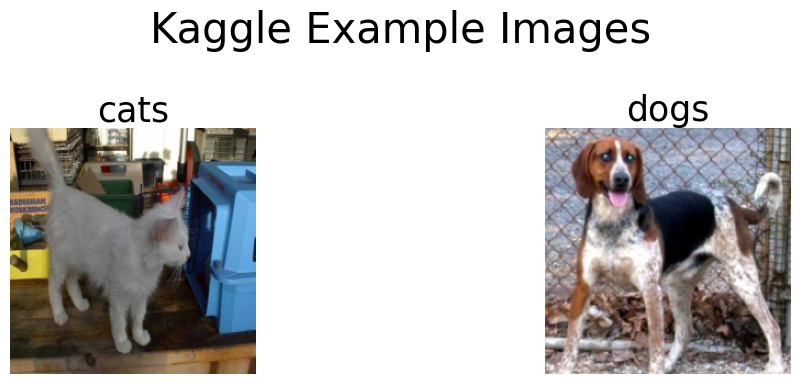

In [31]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Kaggle Example Images', fontsize=30)

for idx, class_idx in enumerate(sorted(example_images.keys())):
    image_tensor, label_tensor = example_images[class_idx]

    # Convert tensor to numpy array
    image_np = image_tensor.numpy()

    # De-normalize the image (reverse the transform: x * 0.5 + 0.5)
    image_np = image_np * 0.5 + 0.5

    # Transpose dimensions from (C, H, W) to (H, W, C) for matplotlib
    image_np = np.transpose(image_np, (1, 2, 0))

    axs[idx].imshow(image_np)
    axs[idx].set_title(classes[class_idx],fontsize=25)
    axs[idx].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

### 3. Modifique la clase CNN para recibir los parámetros adicionales: dimension de la imagen de entrada y numero de clases en la salida.
**Para la entrada:**

 \#MODIFICACIÓN 3 : Dummy tensor usando el tamaño de imagen dado

                                dummy_input = torch.randn(1, 3, 32,32) -> dummy_input = torch.randn(1, 3, input_size, input_size)

**Para la salida:**

\#MODIFICACIÓN 3:  SALIDA EN TERMINOS DEL NUMERO DE CLASES


                                nn.Linear(512, 10) -> nn.Linear(512, num_classes)

In [32]:
import torch.nn as nn
import torch

class CNN(nn.Module):
    def __init__(self, filter_list, input_size, num_classes):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential()
        in_channels = 3 

        for i, num_filters in enumerate(filter_list):
            self.conv_layers.add_module(f"conv{i+1}", nn.Conv2d(in_channels, num_filters, kernel_size=3, padding=1))
            self.conv_layers.add_module(f"relu{i+1}", nn.ReLU())
            self.conv_layers.add_module(f"pool{i+1}", nn.MaxPool2d(kernel_size=2, stride=2))
            in_channels = num_filters # Update in_channels for the next convolutional layer
            
# MODIFICACIÓN 3 : Dummy tensor usando el tamaño de imagen dado
        """
        dummy_input = torch.randn(1, 3, 32, 32) # Batch size 1, 3 channels, 32x32 image (CIFAR-10 size)
        """
        
        dummy_input = torch.randn(1, 3, input_size, input_size)

        with torch.no_grad(): # Disable gradient calculation for this dummy pass
            output_shape = self.conv_layers(dummy_input).shape
            print(f"Output shape after convolutions: {output_shape}")

        # The input size for the FC layer will be the product of channels, height, and width
        fc_input_size = output_shape[1] * output_shape[2] * output_shape[3]

#MODIFICACIÓN 3:  SALIDA EN TERMINOS DEL NUMERO DE CLASES
        self.fc_layers = nn.Sequential(
            nn.Linear(fc_input_size, 512), # First fully connected layer, 512 is an arbitrary choice
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        # Flatten the output of the convolutional layers while preserving the batch size
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

print("CNN class defined successfully.")

CNN class defined successfully.


In [33]:
filter_list = [32, 64, 128]
num_classes = len(trainset_full.classes)
model = CNN([32,64,128], 224, num_classes)
print(model)

Output shape after convolutions: torch.Size([1, 128, 28, 28])
CNN(
  (conv_layers): Sequential(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu1): ReLU()
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu2): ReLU()
    (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu3): ReLU()
    (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=100352, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=2, bias=True)
  )
)


In [34]:
import torch.optim as optim

# 1. Define the device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Move the model to the chosen device
model.to(device)

# 3. Instantiate the CrossEntropyLoss function
criterion = nn.CrossEntropyLoss()

# 4. Initialize the Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [35]:
def train_epoch(model, trainloader, criterion, optimizer, device):
    model.train() # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the gradients

        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward() # Backpropagation
        optimizer.step() # Update weights

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy

print("train_epoch function defined successfully.")

train_epoch function defined successfully.


In [36]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval() # Set the model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad(): # Disable gradient calculation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs) # Forward pass
            loss = criterion(outputs, labels) # Calculate loss

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy

print("evaluate_model function defined successfully.")

evaluate_model function defined successfully.


### 4. Durante el entrenamiento vaya almacenando después de cada época los pesos del mejor modelo. 

La variable **best_val_acc** guarda el mejor accuracy hasta ahora, en cada iteración evalúa y en caso de superarse se actualiza. 

### 5. Si el mejor modelo no a sido mejorado en K=2 épocas posteriores, detenga el entrenamiento
Si **best_val_acc** no se actualiza, el contador **epochs_without_improvement** aumenta.

Si **epochs_without_improvement > K**  se termina el entrenamiento

In [37]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

num_epochs = 10 # You can adjust the number of epochs

# MODIFICACIÓN 4: 
best_val_acc = 0.0 # Mejor accuracy hasta ahora

# MODIFICACIÓN 5: 
epochs_without_improvement = 0 # Contador de épocas sin mejorar el modelo
K = 2 #Número límite de épocas sin mejorar

print("Starting training...")


for epoch in range(1, num_epochs + 1):
    # Train for one epoch
    epoch_train_loss, epoch_train_accuracy = train_epoch(model, trainloader, criterion, optimizer, device)
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Evaluate on the validation set
    epoch_val_loss, epoch_val_accuracy = evaluate_model(model, valloader, criterion, device)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(f"Epoch {epoch}/{num_epochs}: Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

# MODIFICACIÓN 4:  Guardar pesos mejor modelo
    if epoch_val_accuracy > best_val_acc:
        best_val_acc = epoch_val_accuracy
        torch.save(model.state_dict(), "best_model.pth")
        epochs_without_improvement = 0
        print("Best model saved")

    else:
        epochs_without_improvement += 1

# MODIFICACIÓN 5: Detener entrenamiento si hay K épocas sin mejorar
    if epochs_without_improvement >= K:
        print("Early stopping triggered")
        break
        
print("Training complete.")

Starting training...
Epoch 1/10: Train Loss: 0.7352, Train Acc: 0.5459, Val Loss: 0.6764, Val Acc: 0.5863
Best model saved
Epoch 2/10: Train Loss: 0.6505, Train Acc: 0.6132, Val Loss: 0.6395, Val Acc: 0.6262
Best model saved
Epoch 3/10: Train Loss: 0.5857, Train Acc: 0.6888, Val Loss: 0.6009, Val Acc: 0.6575
Best model saved
Epoch 4/10: Train Loss: 0.5283, Train Acc: 0.7324, Val Loss: 0.5492, Val Acc: 0.7212
Best model saved
Epoch 5/10: Train Loss: 0.4597, Train Acc: 0.7810, Val Loss: 0.5147, Val Acc: 0.7512
Best model saved
Epoch 6/10: Train Loss: 0.3475, Train Acc: 0.8468, Val Loss: 0.5265, Val Acc: 0.7362
Epoch 7/10: Train Loss: 0.2054, Train Acc: 0.9160, Val Loss: 0.6982, Val Acc: 0.7488
Early stopping triggered
Training complete.


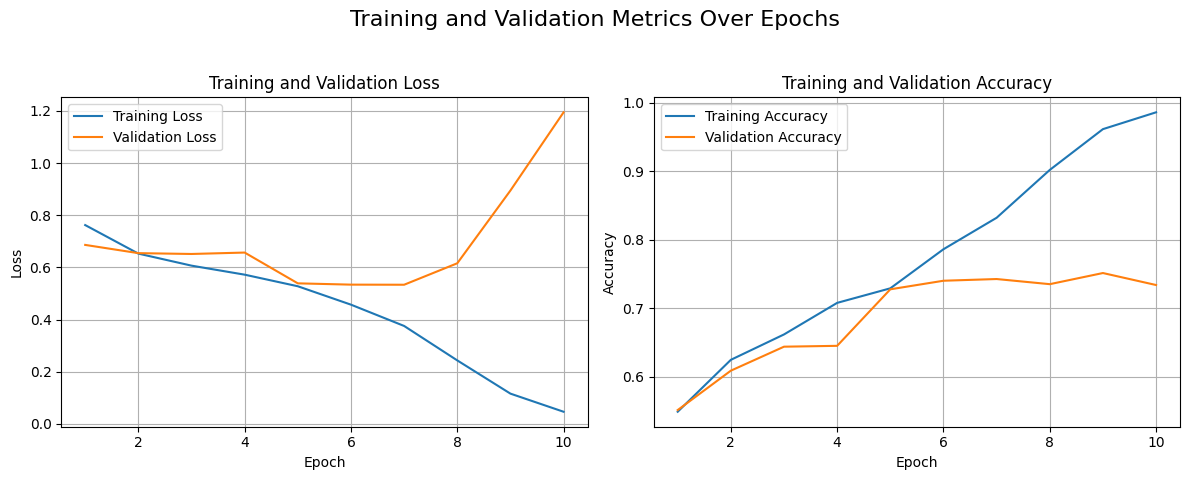

In [15]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# Plot Training and Validation Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.suptitle('Training and Validation Metrics Over Epochs', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

In [16]:
test_loss, test_accuracy = evaluate_model(model, testloader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 1.1612
Test Accuracy: 0.7177


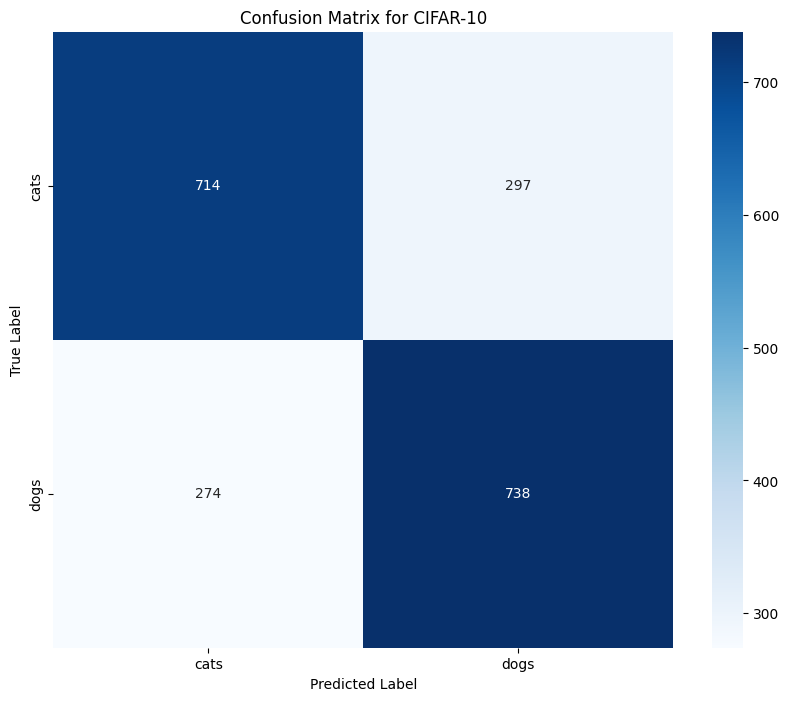

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Set the model to evaluation mode
model.eval()

all_labels = []
all_predictions = []

# Disable gradient calculation for inference
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CIFAR-10')
plt.show()

### 6. Durante el análisis de los resultados reporte unadonde para cada clase (renglón) reporte el "Accuracy, Recall, Precision y el F1-Score". Emplee una estrategia de una clase vs todas las demás para calcular estas métricas.

Para cada clase se codifican los resultados en formato onehot de forma manual. Despuñes se calculan las métricas con sklearn

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print(f"{'Clase':<10} {'Accuracy':<10} {'Recall':<10} {'Precision':<10} {'F1-score':<10}")
for i, cls in enumerate(classes):
    # Clase positiva vs todas las demás
    y_true = [1 if label == i else 0 for label in all_labels]
    y_pred = [1 if pred == i else 0 for pred in all_predictions]
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"{cls:<10} {acc:<10.4f} {rec:<10.4f} {prec:<10.4f} {f1:<10.4f}")

Clase      Accuracy   Recall     Precision  F1-score  
cats       0.7177     0.7062     0.7227     0.7144    
dogs       0.7177     0.7292     0.7130     0.7211    
